In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, Subset
from sklearn.metrics import f1_score
import random

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)
torch.backends.cudnn.deterministic = True

DEVICE       = torch.device("cuda" if torch.cuda.is_available() else "cpu")
NUM_CLASSES  = 100
EPOCHS       = 50
BATCH_SIZE   = 512
LR           = 0.1
MOMENTUM     = 0.9
WEIGHT_DECAY = 5e-4
IMBALANCE_RATIO = 0.01
LAMBDA_RF    = 100   # ← key knob; try 0.01, 0.05, 0.1, 0.5
WARMUP_EPOCHS = 0    # RF reg only kicks in after this epoch

print(f"Device: {DEVICE}")

Device: cuda


In [ ]:
def make_imbalanced_cifar100(imbalance_ratio=0.01, seed=42):
    transform_train = transforms.Compose([
        transforms.RandomCrop(32, padding=4),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize((0.5071, 0.4867, 0.4408),
                             (0.2675, 0.2565, 0.2761)),
    ])
    transform_test = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5071, 0.4867, 0.4408),
                             (0.2675, 0.2565, 0.2761)),
    ])

    full_train = torchvision.datasets.CIFAR100(
        root='./data', train=True, download=True, transform=transform_train)
    test_set   = torchvision.datasets.CIFAR100(
        root='./data', train=False, download=True, transform=transform_test)

    rng = np.random.default_rng(seed)
    targets = np.array(full_train.targets)
    max_samples = 500

    selected_indices = []
    class_counts = []
    for c in range(NUM_CLASSES):
        n_c = max(int(max_samples * (imbalance_ratio ** (c / (NUM_CLASSES - 1)))), 1)
        class_counts.append(n_c)
        idx_c = np.where(targets == c)[0]
        chosen = rng.choice(idx_c, size=n_c, replace=False)
        selected_indices.extend(chosen.tolist())

    imbalanced_train = Subset(full_train, selected_indices)
    return imbalanced_train, test_set, class_counts

train_set, test_set, class_counts = make_imbalanced_cifar100(IMBALANCE_RATIO)
train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_set,  batch_size=256, shuffle=False,
                          num_workers=2, pin_memory=True)

print(f"Total training samples: {len(train_set)}")
print(f"Total test samples:     {len(test_set)}")

100%|██████████| 169M/169M [00:13<00:00, 12.9MB/s]


Total training samples: 10847
Total test samples:     10000


In [ ]:
class ResNet18Penultimate(nn.Module):
    def __init__(self, num_classes=100):
        super().__init__()
        base = torchvision.models.resnet18(weights=None)
        base.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
        base.maxpool = nn.Identity()
        self.backbone = nn.Sequential(
            base.conv1, base.bn1, base.relu, base.maxpool,
            base.layer1, base.layer2, base.layer3, base.layer4,
            base.avgpool,
        )
        self.fc = nn.Linear(512, num_classes)

    def forward(self, x, return_features=False):
        h = self.backbone(x)
        h = torch.flatten(h, 1)
        logits = self.fc(h)
        if return_features:
            return logits, h
        return logits

model_exp2 = ResNet18Penultimate(num_classes=NUM_CLASSES).to(DEVICE)
print(f"Trainable parameters: {sum(p.numel() for p in model_exp2.parameters()):,}")

Trainable parameters: 11,220,132


In [ ]:
def rf_loss_term(logits, features, fc_weight):
    """
    Returns -RF (negative, because we ADD this to CE loss and minimize,
    which means we are maximizing RF = promoting flatness).

    RF = E[||h||^2 * (1 - ||p||^2)] / ||W||^2

    Numerator is high when:
      - features have large norm (spread out representations)
      - softmax is uncertain (1 - ||p||^2 is high when p is uniform)
    Denominator: penalizing large W norm also helps flatness.
    """
    # p         = torch.softmax(logits, dim=1)
    # h_sq      = (features ** 2).sum(dim=1)       # (B,)
    # p_sq      = (p ** 2).sum(dim=1)              # (B,)
    # numerator = (h_sq * (1.0 - p_sq)).mean()
    # w_sq      = (fc_weight ** 2).sum()
    # rf        = numerator / (w_sq + 1e-12)
    # return -rf  # negate: minimizing -RF = maximizing RF
    p    = torch.softmax(logits, dim=1)
    h_n  = features / (features.norm(dim=1, keepdim=True) + 1e-8)  # unit-norm h
    p_sq = (p ** 2).sum(dim=1)
    numerator = (1.0 - p_sq).mean()   # h_sq=1 by construction; only entropy matters
    w_sq = (fc_weight ** 2).sum()
    return numerator / (w_sq + 1e-12)


@torch.no_grad()
def compute_relative_flatness(model, loader, device, max_batches=20):
    model.eval()
    trace_sum = 0.0
    n_samples  = 0

    for batch_idx, (x, _) in enumerate(loader):
        if max_batches is not None and batch_idx >= max_batches:
            break
        x = x.to(device)
        logits, h = model(x, return_features=True)
        p = torch.softmax(logits, dim=1)
        h_sq_norm = (h ** 2).sum(dim=1)
        p_sq_norm = (p ** 2).sum(dim=1)
        trace_sum += (h_sq_norm * (1.0 - p_sq_norm)).sum().item()
        n_samples  += x.size(0)

    mean_trace = trace_sum / n_samples
    W = model.fc.weight
    w_norm_sq = (W ** 2).sum().item()
    rf = mean_trace / (w_norm_sq + 1e-12)
    return rf, mean_trace, w_norm_sq


def train_one_epoch_flat(model, loader, criterion, optimizer, device,
                         lambda_rf, apply_rf_reg):
    model.train()
    total_ce_loss, total_rf_reg, correct, total = 0.0, 0.0, 0, 0

    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()

        logits, h = model(x, return_features=True)
        ce_loss   = criterion(logits, y)

        if apply_rf_reg:
            reg  = rf_loss_term(logits, h, model.fc.weight)
            loss = ce_loss + lambda_rf * reg
            total_rf_reg += reg.item() * x.size(0)   # reg is negative
        else:
            loss = ce_loss

        loss.backward()
        optimizer.step()

        total_ce_loss += ce_loss.item() * x.size(0)
        correct       += logits.argmax(1).eq(y).sum().item()
        total         += x.size(0)

    return total_ce_loss / total, total_rf_reg / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    class_correct = torch.zeros(NUM_CLASSES)
    class_total   = torch.zeros(NUM_CLASSES)
    all_preds, all_targets = [], []

    for x, y in loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        loss   = criterion(logits, y)
        preds  = logits.argmax(1)

        total_loss += loss.item() * x.size(0)
        correct    += preds.eq(y).sum().item()
        total      += x.size(0)
        all_preds.append(preds.cpu())
        all_targets.append(y.cpu())

        for c in range(NUM_CLASSES):
            mask = y.eq(c)
            class_correct[c] += preds[mask].eq(y[mask]).sum().item()
            class_total[c]   += mask.sum().item()

    per_class_acc = (class_correct / class_total.clamp(min=1)).numpy()
    all_preds   = torch.cat(all_preds).numpy()
    all_targets = torch.cat(all_targets).numpy()
    macro_f1    = f1_score(all_targets, all_preds, average="macro")
    weighted_f1 = f1_score(all_targets, all_preds, average="weighted")

    return total_loss / total, correct / total, per_class_acc, macro_f1, weighted_f1

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model_exp2.parameters(), lr=LR,
                      momentum=MOMENTUM, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

history = {
    'train_ce_loss': [], 'train_rf_reg': [], 'train_acc': [],
    'val_loss':      [], 'val_acc':      [],
    'rf':            [],
    'macro_f1':      [], 'weighted_f1':  []
}

print("=" * 70)
print(f"Experiment 2 — RF Flatness Reg (λ={LAMBDA_RF}, warmup={WARMUP_EPOCHS})")
print("=" * 70)

for epoch in range(1, EPOCHS + 1):
    apply_rf_reg = (epoch > WARMUP_EPOCHS)

    tr_ce, tr_reg, tr_acc = train_one_epoch_flat(
        model_exp2, train_loader, criterion, optimizer, DEVICE,
        LAMBDA_RF, apply_rf_reg
    )
    va_loss, va_acc, per_cls, macro_f1, weighted_f1 = evaluate(
        model_exp2, test_loader, criterion, DEVICE
    )
    scheduler.step()

    history['train_ce_loss'].append(tr_ce)
    history['train_rf_reg'].append(tr_reg)
    history['train_acc'].append(tr_acc)
    history['val_loss'].append(va_loss)
    history['val_acc'].append(va_acc)
    history['macro_f1'].append(macro_f1)
    history['weighted_f1'].append(weighted_f1)

    rf, _, _ = compute_relative_flatness(
        model_exp2, train_loader, DEVICE, max_batches=20
    )
    history['rf'].append((epoch, rf))

    reg_status = f"RF_reg={tr_reg:.4f}" if apply_rf_reg else "RF_reg=OFF(warmup)"
    print(
        f"Ep {epoch:3d}/{EPOCHS} | "
        f"CE={tr_ce:.4f} {reg_status} | "
        f"Train acc={tr_acc:.3f} | "
        f"Val acc={va_acc:.3f} | "
        f"Macro-F1={macro_f1:.3f} | "
        f"RF={rf:.4f}"
    )

Experiment 2 — RF Flatness Reg (λ=100, warmup=0)
Ep   1/50 | CE=4.1452 RF_reg=0.0138 | Train acc=0.101 | Val acc=0.015 | Macro-F1=0.003 | RF=2.5959
Ep   2/50 | CE=3.5126 RF_reg=0.0049 | Train acc=0.184 | Val acc=0.060 | Macro-F1=0.031 | RF=0.9442
Ep   3/50 | CE=3.1684 RF_reg=0.0036 | Train acc=0.235 | Val acc=0.090 | Macro-F1=0.044 | RF=0.6263
Ep   4/50 | CE=2.9509 RF_reg=0.0031 | Train acc=0.276 | Val acc=0.104 | Macro-F1=0.066 | RF=0.5884
Ep   5/50 | CE=2.7852 RF_reg=0.0027 | Train acc=0.311 | Val acc=0.115 | Macro-F1=0.078 | RF=0.5690
Ep   6/50 | CE=2.6426 RF_reg=0.0025 | Train acc=0.341 | Val acc=0.112 | Macro-F1=0.071 | RF=0.5273
Ep   7/50 | CE=2.5358 RF_reg=0.0023 | Train acc=0.357 | Val acc=0.150 | Macro-F1=0.104 | RF=0.4458
Ep   8/50 | CE=2.3554 RF_reg=0.0020 | Train acc=0.396 | Val acc=0.149 | Macro-F1=0.098 | RF=0.4767
Ep   9/50 | CE=2.2315 RF_reg=0.0019 | Train acc=0.422 | Val acc=0.160 | Macro-F1=0.115 | RF=0.4634
Ep  10/50 | CE=2.1461 RF_reg=0.0018 | Train acc=0.442 | Val 

In [ ]:
_, final_val_acc, final_per_cls, final_macro_f1, final_weighted_f1 = evaluate(
    model_exp2, test_loader, criterion, DEVICE
)
final_rf, _, _ = compute_relative_flatness(
    model_exp2, train_loader, DEVICE, max_batches=None
)

print("\n── Exp 2 Final Results ────────────────────────────────────")
print(f"Overall test accuracy : {final_val_acc:.4f}   (Exp1 baseline: 0.3942)")
print(f"Macro F1 score        : {final_macro_f1:.4f}   (Exp1 baseline: 0.3547)")
print(f"Weighted F1 score     : {final_weighted_f1:.4f}   (Exp1 baseline: 0.3547)")
print(f"Relative Flatness (RF): {final_rf:.6f}  (Exp1 baseline: 0.012349)")

print("\nPer-class test accuracy:")
for c, acc in enumerate(final_per_cls):
    n_train = class_counts[c]
    bar = "█" * int(acc * 20)
    print(f"  Class {c:2d} (n={n_train:4d}): {acc:.3f}  {bar}")


── Exp 2 Final Results ────────────────────────────────────
Overall test accuracy : 0.3497   (Exp1 baseline: 0.3942)
Macro F1 score        : 0.3088   (Exp1 baseline: 0.3547)
Weighted F1 score     : 0.3088   (Exp1 baseline: 0.3547)
Relative Flatness (RF): 0.040999  (Exp1 baseline: 0.012349)

Per-class test accuracy:
  Class  0 (n= 500): 0.910  ██████████████████
  Class  1 (n= 477): 0.830  ████████████████
  Class  2 (n= 455): 0.680  █████████████
  Class  3 (n= 434): 0.600  ████████████
  Class  4 (n= 415): 0.650  █████████████
  Class  5 (n= 396): 0.750  ███████████████
  Class  6 (n= 378): 0.720  ██████████████
  Class  7 (n= 361): 0.720  ██████████████
  Class  8 (n= 344): 0.800  ████████████████
  Class  9 (n= 328): 0.770  ███████████████
  Class 10 (n= 314): 0.510  ██████████
  Class 11 (n= 299): 0.450  █████████
  Class 12 (n= 286): 0.740  ██████████████
  Class 13 (n= 273): 0.710  ██████████████
  Class 14 (n= 260): 0.470  █████████
  Class 15 (n= 248): 0.600  ████████████
  Cl

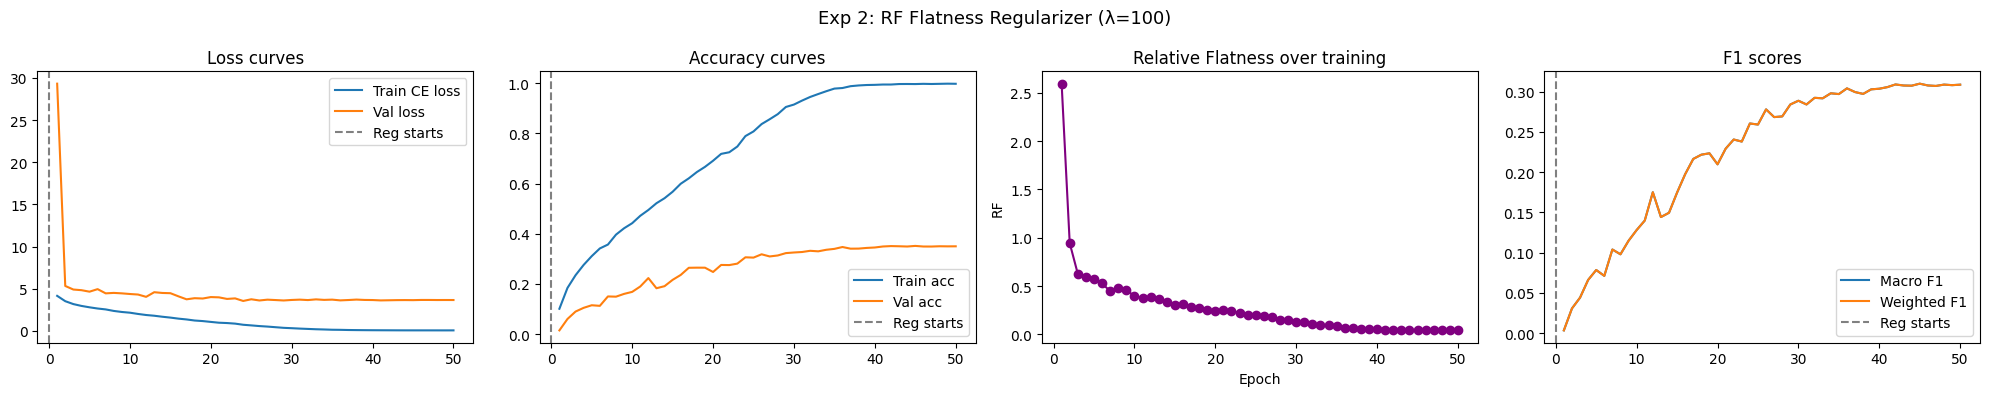

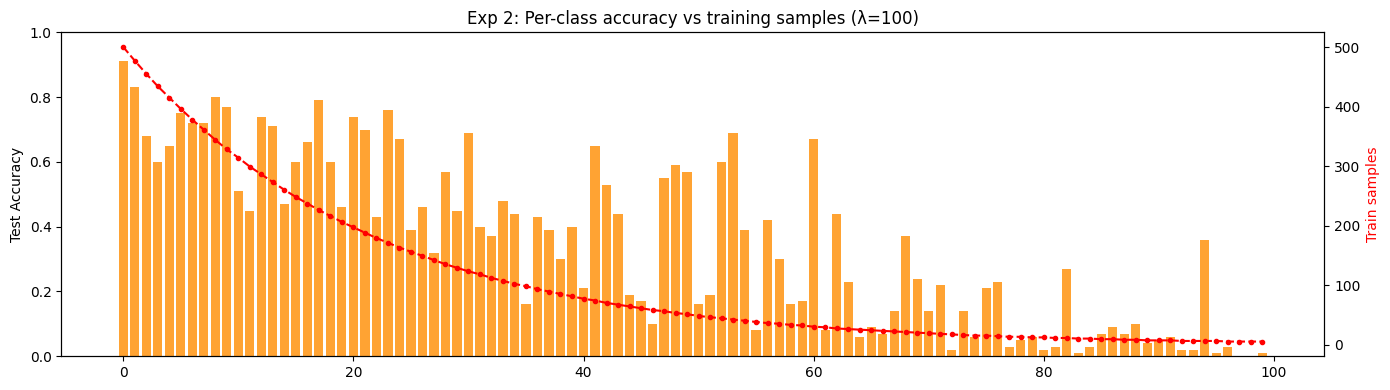

In [ ]:
epochs_x = range(1, EPOCHS + 1)
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
fig.suptitle(f"Exp 2: RF Flatness Regularizer (λ={LAMBDA_RF})", fontsize=13)

axes[0].plot(epochs_x, history['train_ce_loss'], label='Train CE loss')
axes[0].plot(epochs_x, history['val_loss'],      label='Val loss')
axes[0].axvline(WARMUP_EPOCHS, color='gray', linestyle='--', label='Reg starts')
axes[0].set_title("Loss curves"); axes[0].legend()

axes[1].plot(epochs_x, history['train_acc'], label='Train acc')
axes[1].plot(epochs_x, history['val_acc'],   label='Val acc')
axes[1].axvline(WARMUP_EPOCHS, color='gray', linestyle='--', label='Reg starts')
axes[1].set_title("Accuracy curves"); axes[1].legend()

rf_epochs, rf_vals = zip(*history['rf'])
axes[2].plot(rf_epochs, rf_vals, marker='o', color='purple')
axes[2].set_title("Relative Flatness over training")
axes[2].set_xlabel("Epoch"); axes[2].set_ylabel("RF")

axes[3].plot(epochs_x, history['macro_f1'],    label='Macro F1')
axes[3].plot(epochs_x, history['weighted_f1'], label='Weighted F1')
axes[3].axvline(WARMUP_EPOCHS, color='gray', linestyle='--', label='Reg starts')
axes[3].set_title("F1 scores"); axes[3].legend()

plt.tight_layout()
plt.savefig("exp2_flatness_reg.png", dpi=150)
plt.show()

# Per-class accuracy bar chart
fig2, ax = plt.subplots(figsize=(14, 4))
x = np.arange(NUM_CLASSES)
ax.bar(x, final_per_cls, color='darkorange', alpha=0.8, label='Exp2 (RF reg)')
ax2 = ax.twinx()
ax2.plot(x, class_counts, 'r--o', markersize=3, label='Train samples')
ax2.set_ylabel("Train samples", color='red')
ax.set_ylabel("Test Accuracy"); ax.set_ylim(0, 1)
ax.set_title(f"Exp 2: Per-class accuracy vs training samples (λ={LAMBDA_RF})")
plt.tight_layout()
plt.savefig("exp2_perclass.png", dpi=150)
plt.show()